# Exploratory Clustering of ASEAN Rice-Supply Profiles

Notebook ini menyatukan data neraca beras AFSIS, perdagangan bilateral UN Comtrade, yield padi, RONI, dan batas administrasi negara menjadi satu **master dataframe tingkat negara**. Percobaan clustering dilakukan untuk $k=2$, $k=3$, dan $k=4$ menggunakan hierarchical clustering metode Ward.

## Keputusan metodologis utama

- Daftar ASEAN 2026 berisi **11 negara**, termasuk Timor-Leste yang resmi menjadi anggota ke-11 pada 26 Oktober 2025.
- Tabel AFSIS yang dilampirkan hanya mencakup 10 negara. Timor-Leste tetap dimasukkan ke master dataframe, tetapi tidak dipaksakan masuk clustering utama karena indikator domestic buffer belum tersedia.
- Clustering utama menggunakan dua indikator yang tersedia konsisten dan tidak mengulang informasi yang sama:
  1. `Production_Shortfall_pct`, yaitu bagian kebutuhan yang belum ditutup produksi domestik.
  2. `Beginning_Stock_to_Use_pct`, yaitu stok awal dibandingkan domestic utilization.
- `Import_Reliance_pct` tidak masuk model utama karena sangat berkorelasi dengan production shortfall. `Supplier_HHI` dan supplier climate exposure tetap dihitung, tetapi hanya menjadi diagnosis tambahan karena data perdagangan hanya mencakup empat reporter.
- Hasil disebut **exploratory structural profiles**, bukan prediksi krisis atau peringkat risiko pasti.

Sumber keanggotaan: https://asean.org/forging-a-new-era-timor-leste-admitted-into-asean/


## 1. Persiapan pustaka dan lokasi file

Cell berikut memuat pustaka analisis, menetapkan tampilan grafik, lalu mencari file pada dua lokasi: folder proyek Windows milikmu dan folder kerja tempat notebook dijalankan. Dengan cara ini, notebook tetap bisa digunakan di komputer lokal maupun setelah dipindahkan bersama file CSV.

Jika nama file mendapat tambahan seperti `(3)` atau `(4)`, fungsi `resolve_file()` tetap dapat menemukannya melalui pola nama.


In [1]:
from pathlib import Path
from io import StringIO
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import linregress, t as student_t
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

# Ubah hanya baris ini jika folder proyekmu berbeda.
WINDOWS_PROJECT_DIR = Path(r"C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO")

CANDIDATE_DIRS = [
    WINDOWS_PROJECT_DIR,
    Path.cwd(),
    Path.cwd() / "upload",
    Path.cwd().parent,
]

def resolve_file(patterns, required=True):
    # Cari file pertama yang cocok pada seluruh kandidat folder.
    if isinstance(patterns, str):
        patterns = [patterns]
    for folder in CANDIDATE_DIRS:
        if not folder.exists():
            continue
        for pattern in patterns:
            matches = sorted(folder.glob(pattern))
            if matches:
                return matches[0]
    if required:
        raise FileNotFoundError(
            f"File tidak ditemukan. Pola: {patterns}. "
            "Letakkan file pada folder proyek atau folder yang sama dengan notebook."
        )
    return None

RONI_PATH = resolve_file(["RONI_3_Months*.csv", "RONI*.csv"])
TRADE_PATH = resolve_file(["TradeData*.csv", "*TradeData*.csv"])
YIELD_PATH = resolve_file(["rice-yields*.csv", "*rice*yield*.csv"])

SHP_CANDIDATES = [
    WINDOWS_PROJECT_DIR / "ne_10m_admin_0_countries" / "ne_10m_admin_0_countries.shp",
    Path.cwd() / "ne_10m_admin_0_countries" / "ne_10m_admin_0_countries.shp",
    Path.cwd() / "upload" / "ne_10m_admin_0_countries.shp",
    Path.cwd() / "ne_10m_admin_0_countries.shp",
]
SHP_PATH = next((p for p in SHP_CANDIDATES if p.exists()), SHP_CANDIDATES[0])

print("RONI :", RONI_PATH)
print("Trade:", TRADE_PATH)
print("Yield:", YIELD_PATH)
print("SHP   :", SHP_PATH)


RONI : /workspace/scratch/faabc4ee17d4/upload/RONI_3_Months(3).csv
Trade: /workspace/scratch/faabc4ee17d4/upload/TradeData_8_27_2026_21_50_21(3).csv
Yield: /workspace/scratch/faabc4ee17d4/upload/rice-yields(4).csv
SHP   : /workspace/scratch/faabc4ee17d4/upload/ne_10m_admin_0_countries.shp


## 2. Menyusun data neraca beras AFSIS

Angka pada Table 7, Table 8, dan Table 9 yang kamu lampirkan ditranskripsikan menjadi data panjang `country-year`. Seluruh volume menggunakan ton beras giling. Setelah itu dilakukan pemeriksaan keseimbangan sederhana:

$$BeginningStock + Production + Import \approx Utilization + Export + EndingStock$$

Selisih satu ton masih dapat terjadi karena angka pada tabel dibulatkan. Tahun 2026 dipakai untuk profil utama karena merupakan horizon infografis, tetapi statusnya harus tetap ditulis sebagai proyeksi AFSIS.


In [2]:
afsis_csv = '''Year,Country,Beginning_Stock_ton,Production_ton,Import_ton,Domestic_Utilization_ton,Export_ton,Ending_Stock_ton
2024,Brunei Darussalam,8551,2348,29127,31097,0,8928
2024,Cambodia,2603849,8889320,0,7421155,645872,3426142
2024,Indonesia,4134399,34021974,4381671,34135743,24,8402277
2024,Lao PDR,56953,2250444,39632,2192061,45889,109079
2024,Malaysia,0,1317825,1686054,2900146,103733,0
2024,Myanmar,11356172,19209975,0,12360717,1841100,16364330
2024,Philippines,2100000,13154688,4780000,16597208,0,3437480
2024,Singapore,0,0,448295,260192,188103,0
2024,Thailand,6716104,21760946,12971,11039810,9987265,7462946
2024,Viet Nam,2775597,28239998,2936700,21475711,10158000,2318584
2025,Brunei Darussalam,8928,2613,25721,29487,0,7776
2025,Cambodia,3426142,9069846,0,7886894,665248,3943846
2025,Indonesia,8402277,38651626,532810,35057311,55,12529347
2025,Lao PDR,109079,2251398,34820,2287391,61683,46223
2025,Malaysia,0,1343880,1640914,2887728,97066,0
2025,Myanmar,16364330,19128054,0,13232275,1641188,20618921
2025,Philippines,3437480,12741675,4000000,17288305,0,2890850
2025,Singapore,0,0,538925,269267,269658,0
2025,Thailand,7462946,23137405,19389,11071810,8030000,11517930
2025,Viet Nam,2318584,28417620,3203906,21202316,10093000,2644794
2026,Brunei Darussalam,7776,2746,24048,29281,0,5289
2026,Cambodia,3943846,8960000,0,8096800,685206,4121841
2026,Indonesia,12529347,39260339,393131,31103146,804,21078867
2026,Lao PDR,46223,2382600,36258,2325052,54663,85367
2026,Malaysia,0,1357154,1634311,2889000,102465,0
2026,Myanmar,20618921,19023298,0,15405214,2110430,22126575
2026,Philippines,2890850,12791563,4000000,17471531,0,2210882
2026,Singapore,0,0,493610,264730,228880,0
2026,Thailand,11517930,23032393,20000,11079810,7530000,15960513
2026,Viet Nam,2644794,29319578,3203906,21518349,9562858,4087071
'''

afsis_long = pd.read_csv(StringIO(afsis_csv))

afsis_long["Supply_Total_ton"] = (
    afsis_long["Beginning_Stock_ton"]
    + afsis_long["Production_ton"]
    + afsis_long["Import_ton"]
)
afsis_long["Demand_Total_ton"] = (
    afsis_long["Domestic_Utilization_ton"]
    + afsis_long["Export_ton"]
    + afsis_long["Ending_Stock_ton"]
)
afsis_long["Balance_Error_ton"] = (
    afsis_long["Supply_Total_ton"] - afsis_long["Demand_Total_ton"]
)

afsis_long["SSR_pct"] = (
    afsis_long["Production_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)
afsis_long["Production_Shortfall_pct"] = (
    100 - afsis_long["SSR_pct"]
).clip(lower=0)
afsis_long["Import_Reliance_pct"] = (
    afsis_long["Import_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)
afsis_long["Beginning_Stock_to_Use_pct"] = (
    afsis_long["Beginning_Stock_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)
afsis_long["Ending_Stock_to_Use_pct"] = (
    afsis_long["Ending_Stock_ton"]
    / afsis_long["Domestic_Utilization_ton"]
    * 100
)

print("Jumlah observasi AFSIS:", len(afsis_long))
print("Maksimum selisih neraca akibat pembulatan:", int(afsis_long["Balance_Error_ton"].abs().max()), "ton")
print(
    afsis_long.query("Year == 2026")[[
        "Country", "SSR_pct", "Production_Shortfall_pct",
        "Import_Reliance_pct", "Beginning_Stock_to_Use_pct"
    ]].round(2).to_string(index=False)
)


Jumlah observasi AFSIS: 30
Maksimum selisih neraca akibat pembulatan: 1 ton
          Country  SSR_pct  Production_Shortfall_pct  Import_Reliance_pct  Beginning_Stock_to_Use_pct
Brunei Darussalam     9.38                     90.62                82.13                       26.56
         Cambodia   110.66                      0.00                 0.00                       48.71
        Indonesia   126.23                      0.00                 1.26                       40.28
          Lao PDR   102.48                      0.00                 1.56                        1.99
         Malaysia    46.98                     53.02                56.57                        0.00
          Myanmar   123.49                      0.00                 0.00                      133.84
      Philippines    73.21                     26.79                22.89                       16.55
        Singapore     0.00                    100.00               186.46                        0.00
      

## 3. Mengolah struktur pemasok dari UN Comtrade

Data perdagangan berisi HS 1006 untuk tahun 2024. Baris `World` dikeluarkan karena merupakan agregat, bukan pemasok. Supplier share dihitung dari `netWgt`, lalu diturunkan menjadi:

$$HHI_i = \sum_j s_{ij}^2$$

$$EffectiveSuppliers_i = \frac{1}{HHI_i}$$

HHI dan effective suppliers tidak digunakan bersamaan dalam clustering karena keduanya membawa informasi yang sama. Pada file yang tersedia, reporter hanya Brunei Darussalam, Malaysia, Philippines, dan Singapore.


In [3]:
# index_col=False diperlukan karena file ekspor memiliki delimiter kosong tambahan di akhir baris.
trade_raw = pd.read_csv(TRADE_PATH, index_col=False)

trade = trade_raw.copy()
trade["refYear"] = pd.to_numeric(trade["refYear"], errors="coerce")
trade["cmdCode"] = trade["cmdCode"].astype(str).str.replace(".0", "", regex=False)
trade["netWgt"] = pd.to_numeric(trade["netWgt"], errors="coerce")

trade_detail = trade.loc[
    trade["flowDesc"].eq("Import")
    & trade["refYear"].eq(2024)
    & trade["cmdCode"].eq("1006")
    & trade["partnerDesc"].ne("World")
    & trade["netWgt"].gt(0)
].copy()

trade_detail["Supplier_Share"] = trade_detail.groupby("reporterDesc")["netWgt"].transform(
    lambda s: s / s.sum()
)

def trade_summary_one(group):
    top_row = group.loc[group["Supplier_Share"].idxmax()]
    hhi = np.square(group["Supplier_Share"]).sum()
    return pd.Series({
        "Trade_Year": 2024,
        "Supplier_HHI": hhi,
        "Effective_Suppliers": 1 / hhi,
        "Top_Supplier": top_row["partnerDesc"],
        "Top_Supplier_Share_pct": top_row["Supplier_Share"] * 100,
        "Observed_Supplier_Count": group["partnerDesc"].nunique(),
        "Bilateral_Import_kg": group["netWgt"].sum(),
    })

trade_summary = (
    trade_detail.groupby("reporterDesc", group_keys=False)
    .apply(trade_summary_one, include_groups=False)
    .reset_index()
    .rename(columns={"reporterDesc": "Country"})
)

print("Reporter yang tersedia:", ", ".join(trade_summary["Country"]))
print(trade_summary.round(3).to_string(index=False))


Reporter yang tersedia: Brunei Darussalam, Malaysia, Philippines, Singapore
          Country  Trade_Year  Supplier_HHI  Effective_Suppliers Top_Supplier  Top_Supplier_Share_pct  Observed_Supplier_Count  Bilateral_Import_kg
Brunei Darussalam        2024         0.477                2.097     Thailand                  62.319                       12         3.128568e+07
         Malaysia        2024         0.270                3.699     Viet Nam                  40.561                       13         1.695310e+09
      Philippines        2024         0.578                1.730     Viet Nam                  74.423                       14         4.770089e+09
        Singapore        2024         0.291                3.434        India                  35.262                       26         4.485031e+08


## 4. Membersihkan RONI dan menghitung sensitivitas yield

File RONI memiliki header yang berulang setiap beberapa baris. Header tersebut dibuang, lalu 12 musim tiga-bulanan dirata-ratakan menjadi indikator RONI tahunan. Periode 1990 sampai 2023 digunakan agar seluruh negara produsen memiliki rentang yang sama dan tahun belum lengkap tidak ikut dianalisis.

Yield mentah tidak dibandingkan langsung karena perbedaan teknologi dan level produktivitas. Untuk setiap negara, notebook terlebih dahulu membentuk tren log-linear dan menghitung anomaly terhadap tren:

$$YieldAnomaly_{it}=\left(\frac{Yield_{it}}{TrendYield_{it}}-1\right)\times100$$

Kemudian anomaly diregresikan secara sederhana terhadap RONI tahunan. Koefisien negatif berarti yield secara historis cenderung lebih rendah ketika RONI meningkat. Hasil ini bersifat deskriptif, bukan hubungan kausal.


In [4]:
roni_raw = pd.read_csv(RONI_PATH, encoding="utf-8-sig")
roni = roni_raw.loc[pd.to_numeric(roni_raw["Year"], errors="coerce").notna()].copy()
roni["Year"] = pd.to_numeric(roni["Year"], errors="coerce").astype(int)

season_cols = [c for c in roni.columns if c != "Year"]
for col in season_cols:
    roni[col] = pd.to_numeric(roni[col], errors="coerce")

roni["RONI_Annual"] = roni[season_cols].mean(axis=1, skipna=True)
roni["RONI_Season_Count"] = roni[season_cols].notna().sum(axis=1)
roni_annual = roni[["Year", "RONI_Annual", "RONI_Season_Count"]].copy()

print("Rentang RONI bersih:", int(roni_annual["Year"].min()), "-", int(roni_annual["Year"].max()))
print("Baris tahun duplikat setelah header dibuang:", int(roni_annual["Year"].duplicated().sum()))
print(roni_annual.tail(8).round(3).to_string(index=False))


Rentang RONI bersih: 1950 - 2026
Baris tahun duplikat setelah header dibuang: 0
 Year  RONI_Annual  RONI_Season_Count
 2019        0.300                 12
 2020       -0.700                 12
 2021       -0.967                 12
 2022       -1.083                 12
 2023        0.358                 12
 2024       -0.242                 12
 2025       -0.725                 12
 2026       -0.100                  6


In [5]:
yield_raw = pd.read_csv(YIELD_PATH)
yield_value_col = next(c for c in yield_raw.columns if "yield" in c.lower() and c not in {"Entity", "Year"})

country_name_map = {
    "Brunei": "Brunei Darussalam",
    "East Timor": "Timor-Leste",
    "Laos": "Lao PDR",
    "Vietnam": "Viet Nam",
}

yield_clean = yield_raw.rename(columns={yield_value_col: "Rice_Yield_ton_per_ha"}).copy()
yield_clean["Country"] = yield_clean["Entity"].replace(country_name_map)
yield_clean["Year"] = pd.to_numeric(yield_clean["Year"], errors="coerce")
yield_clean["Rice_Yield_ton_per_ha"] = pd.to_numeric(
    yield_clean["Rice_Yield_ton_per_ha"], errors="coerce"
)
yield_clean = yield_clean.loc[
    yield_clean["Year"].between(1990, 2023)
    & yield_clean["Rice_Yield_ton_per_ha"].gt(0)
].copy()

yield_roni = yield_clean.merge(
    roni_annual.query("RONI_Season_Count == 12")[["Year", "RONI_Annual"]],
    on="Year",
    how="inner",
)

print("Negara yield:", ", ".join(sorted(yield_roni["Country"].unique())))
print("Periode analisis:", int(yield_roni["Year"].min()), "-", int(yield_roni["Year"].max()))
print(yield_roni.groupby("Country")["Year"].count().rename("n_years").to_string())


Negara yield: Brunei Darussalam, Cambodia, Indonesia, Lao PDR, Malaysia, Myanmar, Philippines, Thailand, Timor-Leste, Viet Nam
Periode analisis: 1990 - 2023
Country
Brunei Darussalam    34
Cambodia             34
Indonesia            34
Lao PDR              34
Malaysia             34
Myanmar              34
Philippines          34
Thailand             34
Timor-Leste          34
Viet Nam             34


In [6]:
climate_rows = []
yield_anomaly_parts = []

for country, group in yield_roni.groupby("Country"):
    g = group.dropna(subset=["Year", "Rice_Yield_ton_per_ha", "RONI_Annual"]).copy()
    years = g["Year"].to_numpy(dtype=float)
    observed = g["Rice_Yield_ton_per_ha"].to_numpy(dtype=float)

    trend_coef = np.polyfit(years, np.log(observed), deg=1)
    trend_yield = np.exp(np.polyval(trend_coef, years))
    anomaly = (observed / trend_yield - 1) * 100
    g["Yield_Anomaly_pct"] = anomaly
    yield_anomaly_parts.append(g)

    fit = linregress(g["RONI_Annual"], g["Yield_Anomaly_pct"])
    df_resid = len(g) - 2
    critical_t = student_t.ppf(0.975, df=df_resid)
    ci_low = fit.slope - critical_t * fit.stderr
    ci_high = fit.slope + critical_t * fit.stderr

    climate_rows.append({
        "Country": country,
        "Climate_n_years": len(g),
        "Yield_RONI_Beta_pp_per_1C": fit.slope,
        "Yield_RONI_CI_low": ci_low,
        "Yield_RONI_CI_high": ci_high,
        "Yield_RONI_pvalue": fit.pvalue,
        "Yield_RONI_R2": fit.rvalue ** 2,
        # Penalty hanya mengambil arah negatif. Nilai positif tidak dianggap loss.
        "Domestic_Climate_Penalty_pp_per_1C": max(0, -fit.slope),
    })

yield_anomaly = pd.concat(yield_anomaly_parts, ignore_index=True)
climate_sensitivity = pd.DataFrame(climate_rows).sort_values(
    "Domestic_Climate_Penalty_pp_per_1C", ascending=False
)
climate_sensitivity["Climate_Evidence"] = np.select(
    [
        (climate_sensitivity["Yield_RONI_Beta_pp_per_1C"] < 0)
        & (climate_sensitivity["Yield_RONI_pvalue"] < 0.05),
        climate_sensitivity["Yield_RONI_Beta_pp_per_1C"] < 0,
    ],
    ["Negative, p<0.05", "Negative, uncertain"],
    default="No negative association",
)

print(climate_sensitivity.round(3).to_string(index=False))


          Country  Climate_n_years  Yield_RONI_Beta_pp_per_1C  Yield_RONI_CI_low  Yield_RONI_CI_high  Yield_RONI_pvalue  Yield_RONI_R2  Domestic_Climate_Penalty_pp_per_1C        Climate_Evidence
         Cambodia               34                     -4.911             -8.883              -0.939              0.017          0.165                               4.911        Negative, p<0.05
         Viet Nam               34                     -1.159             -3.980               1.661              0.409          0.021                               1.159     Negative, uncertain
          Myanmar               34                     -1.110             -4.058               1.837              0.448          0.018                               1.110     Negative, uncertain
         Thailand               34                     -1.004             -5.114               3.107              0.622          0.008                               1.004     Negative, uncertain
Brunei Darussalam        

### Supplier-weighted climate exposure

Koefisien yield pemasok digabungkan dengan supplier share:

$$SupplierClimateExposure_i = \sum_j s_{ij}\max(0,-\beta_j)$$

Karena file yield hanya memuat negara ASEAN, beberapa pemasok besar dari luar kawasan seperti India dan Pakistan belum memiliki koefisien. Notebook menyimpan `Climate_Supplier_Coverage_pct` dan hanya menganggap exposure layak dipakai jika minimal 80% impor bilateral telah tercakup. Nilai di bawah ambang tidak diimputasi.


In [7]:
partner_name_map = {
    "Brunei": "Brunei Darussalam",
    "Lao PDR": "Lao PDR",
    "Viet Nam": "Viet Nam",
}

supplier_penalty = climate_sensitivity[[
    "Country", "Domestic_Climate_Penalty_pp_per_1C"
]].rename(columns={
    "Country": "Supplier_Country",
    "Domestic_Climate_Penalty_pp_per_1C": "Supplier_Climate_Penalty_pp_per_1C",
})

trade_climate = trade_detail.copy()
trade_climate["Supplier_Country"] = trade_climate["partnerDesc"].replace(partner_name_map)
trade_climate = trade_climate.merge(supplier_penalty, on="Supplier_Country", how="left")
trade_climate["Known_Climate_Contribution"] = (
    trade_climate["Supplier_Share"]
    * trade_climate["Supplier_Climate_Penalty_pp_per_1C"].fillna(0)
)
trade_climate["Known_Climate_Share"] = np.where(
    trade_climate["Supplier_Climate_Penalty_pp_per_1C"].notna(),
    trade_climate["Supplier_Share"],
    0,
)

supplier_exposure = (
    trade_climate.groupby("reporterDesc")
    .agg(
        Climate_Supplier_Coverage=("Known_Climate_Share", "sum"),
        Supplier_Climate_Exposure_partial=("Known_Climate_Contribution", "sum"),
    )
    .reset_index()
    .rename(columns={"reporterDesc": "Country"})
)
supplier_exposure["Climate_Supplier_Coverage_pct"] = (
    supplier_exposure["Climate_Supplier_Coverage"] * 100
)
supplier_exposure["Supplier_Climate_Exposure_pp_per_1C"] = np.where(
    supplier_exposure["Climate_Supplier_Coverage"] >= 0.80,
    supplier_exposure["Supplier_Climate_Exposure_partial"],
    np.nan,
)

print(supplier_exposure.round(3).to_string(index=False))


          Country  Climate_Supplier_Coverage  Supplier_Climate_Exposure_partial  Climate_Supplier_Coverage_pct  Supplier_Climate_Exposure_pp_per_1C
Brunei Darussalam                      0.917                              2.045                         91.738                                2.045
         Malaysia                      0.582                              0.802                         58.207                                  NaN
      Philippines                      0.923                              1.050                         92.326                                1.050
        Singapore                      0.603                              0.752                         60.348                                  NaN


## 5. Menggabungkan seluruh sumber menjadi satu master dataframe

Satu negara menjadi satu baris. Kolom `Eligible_Main_Cluster` menandai negara yang memiliki kedua indikator model utama. Timor-Leste dipertahankan agar dataframe benar-benar mengikuti daftar 11 anggota ASEAN 2026, sedangkan nilai yang belum tersedia dibiarkan `NaN`.

Perhatikan bahwa dataframe ini menggabungkan horizon berbeda:

- domestic balance dan stocks: proyeksi AFSIS 2026;
- struktur pemasok: UN Comtrade 2024;
- respons iklim: hubungan historis 1990 sampai 2023.

Karena itu, hasil dibaca sebagai profil struktural, bukan keadaan pada satu tahun observasi yang identik.


In [8]:
ASEAN_2026 = [
    "Brunei Darussalam", "Cambodia", "Indonesia", "Lao PDR", "Malaysia",
    "Myanmar", "Philippines", "Singapore", "Thailand", "Timor-Leste", "Viet Nam",
]

roster = pd.DataFrame({
    "Country": ASEAN_2026,
    "ASEAN_Member_2026": True,
})

afsis_2026 = afsis_long.query("Year == 2026").copy()
afsis_2026 = afsis_2026.rename(columns={"Year": "AFSIS_Year"})
afsis_2026["AFSIS_Status"] = "Projection supplied in AFSIS Table 9-11"

master = (
    roster
    .merge(afsis_2026, on="Country", how="left")
    .merge(trade_summary, on="Country", how="left")
    .merge(climate_sensitivity, on="Country", how="left")
    .merge(supplier_exposure, on="Country", how="left")
)

master["Has_AFSIS_2026"] = master["AFSIS_Year"].notna()
master["Has_Trade_2024"] = master["Supplier_HHI"].notna()
master["Has_Domestic_Climate_Estimate"] = master["Yield_RONI_Beta_pp_per_1C"].notna()
master["Has_Validated_Supplier_Climate_Exposure"] = master[
    "Supplier_Climate_Exposure_pp_per_1C"
].notna()

MAIN_FEATURES = ["Production_Shortfall_pct", "Beginning_Stock_to_Use_pct"]
master["Eligible_Main_Cluster"] = master[MAIN_FEATURES].notna().all(axis=1)

master_columns = [
    "Country", "ASEAN_Member_2026", "AFSIS_Year", "AFSIS_Status",
    "Production_ton", "Domestic_Utilization_ton", "Import_ton", "Export_ton",
    "Beginning_Stock_ton", "Ending_Stock_ton", "SSR_pct",
    "Production_Shortfall_pct", "Import_Reliance_pct",
    "Beginning_Stock_to_Use_pct", "Ending_Stock_to_Use_pct",
    "Trade_Year", "Supplier_HHI", "Effective_Suppliers", "Top_Supplier",
    "Top_Supplier_Share_pct", "Observed_Supplier_Count",
    "Yield_RONI_Beta_pp_per_1C", "Yield_RONI_CI_low", "Yield_RONI_CI_high",
    "Yield_RONI_pvalue", "Yield_RONI_R2", "Domestic_Climate_Penalty_pp_per_1C",
    "Climate_Evidence", "Climate_Supplier_Coverage_pct",
    "Supplier_Climate_Exposure_partial", "Supplier_Climate_Exposure_pp_per_1C",
    "Has_AFSIS_2026", "Has_Trade_2024", "Has_Domestic_Climate_Estimate",
    "Has_Validated_Supplier_Climate_Exposure", "Eligible_Main_Cluster",
]
master = master[master_columns].sort_values("Country").reset_index(drop=True)

print("Ukuran master dataframe:", master.shape)
print("Eligible clustering utama:", int(master["Eligible_Main_Cluster"].sum()), "dari", len(master), "anggota")
print(master.round(3).to_string(index=False))


Ukuran master dataframe: (11, 36)
Eligible clustering utama: 10 dari 11 anggota
          Country  ASEAN_Member_2026  AFSIS_Year                            AFSIS_Status  Production_ton  Domestic_Utilization_ton  Import_ton  Export_ton  Beginning_Stock_ton  Ending_Stock_ton  SSR_pct  Production_Shortfall_pct  Import_Reliance_pct  Beginning_Stock_to_Use_pct  Ending_Stock_to_Use_pct  Trade_Year  Supplier_HHI  Effective_Suppliers Top_Supplier  Top_Supplier_Share_pct  Observed_Supplier_Count  Yield_RONI_Beta_pp_per_1C  Yield_RONI_CI_low  Yield_RONI_CI_high  Yield_RONI_pvalue  Yield_RONI_R2  Domestic_Climate_Penalty_pp_per_1C        Climate_Evidence  Climate_Supplier_Coverage_pct  Supplier_Climate_Exposure_partial  Supplier_Climate_Exposure_pp_per_1C  Has_AFSIS_2026  Has_Trade_2024  Has_Domestic_Climate_Estimate  Has_Validated_Supplier_Climate_Exposure  Eligible_Main_Cluster
Brunei Darussalam               True      2026.0 Projection supplied in AFSIS Table 9-11          2746.0              

## 6. Menyeleksi variabel agar tidak terjadi double counting

Sebelum clustering, notebook memeriksa korelasi indikator AFSIS yang lengkap. Aturan praktis yang digunakan adalah $|r| \geq 0.80$ sebagai tanda dua indikator sangat berdekatan informasinya.

- `Production_Shortfall_pct` dipertahankan karena langsung menjawab apakah produksi domestik mencukupi kebutuhan.
- `Import_Reliance_pct` hanya menjadi kolom deskriptif apabila korelasinya dengan shortfall terlalu tinggi.
- Beginning dan ending stock ratio tidak dipakai bersamaan. Beginning stock dipilih karena sesuai dengan food security ratio pada Table 11 dan menunjukkan buffer yang sudah tersedia pada awal periode.
- HHI dan climate exposure tidak masuk model utama karena cakupannya belum cukup untuk seluruh sampel.


In [9]:
main_sample = master.loc[master["Eligible_Main_Cluster"]].copy().reset_index(drop=True)

candidate_complete = [
    "Production_Shortfall_pct",
    "Import_Reliance_pct",
    "Beginning_Stock_to_Use_pct",
    "Ending_Stock_to_Use_pct",
]
corr = main_sample[candidate_complete].corr()

coverage_table = pd.DataFrame({
    "Indicator": [
        "Production_Shortfall_pct", "Import_Reliance_pct",
        "Beginning_Stock_to_Use_pct", "Ending_Stock_to_Use_pct",
        "Supplier_HHI", "Domestic_Climate_Penalty_pp_per_1C",
        "Supplier_Climate_Exposure_pp_per_1C",
    ],
    "Dimension": [
        "Domestic production adequacy", "Import dependence",
        "Available stock buffer", "Post-period stock buffer",
        "Supplier concentration", "Domestic climate response",
        "Imported supplier climate exposure",
    ],
})
coverage_table["Available_n_of_11"] = coverage_table["Indicator"].map(master.notna().sum())
coverage_table["Decision_Main_Model"] = [
    "Keep", "Descriptive: redundant with shortfall",
    "Keep", "Descriptive: redundant with beginning stock",
    "Descriptive: only four reporters", "Descriptive: Singapore missing",
    "Descriptive: coverage threshold met by only part of sample",
]

print("Korelasi indikator AFSIS:")
print(corr.round(3).to_string())
print("\nCakupan dan keputusan variabel:")
print(coverage_table.to_string(index=False))

shortfall_import_corr = corr.loc["Production_Shortfall_pct", "Import_Reliance_pct"]
stock_corr = corr.loc["Beginning_Stock_to_Use_pct", "Ending_Stock_to_Use_pct"]
assert abs(shortfall_import_corr) >= 0.80, "Periksa kembali keputusan redundansi shortfall dan import reliance."
assert abs(stock_corr) >= 0.80, "Periksa kembali keputusan redundansi beginning dan ending stocks."

print("\nVariabel final clustering:", MAIN_FEATURES)


Korelasi indikator AFSIS:
                            Production_Shortfall_pct  Import_Reliance_pct  Beginning_Stock_to_Use_pct  Ending_Stock_to_Use_pct
Production_Shortfall_pct                       1.000                0.921                      -0.454                   -0.518
Import_Reliance_pct                            0.921                1.000                      -0.454                   -0.486
Beginning_Stock_to_Use_pct                    -0.454               -0.454                       1.000                    0.976
Ending_Stock_to_Use_pct                       -0.518               -0.486                       0.976                    1.000

Cakupan dan keputusan variabel:
                          Indicator                          Dimension  Available_n_of_11                                        Decision_Main_Model
           Production_Shortfall_pct       Domestic production adequacy                 10                                                       Keep
        

## 7. Standardisasi

Walaupun kedua indikator sama-sama berupa persen, distribusinya sangat berbeda. Production shortfall memiliki banyak nilai nol, sedangkan stock-to-use memiliki nilai ekstrem di Myanmar dan Thailand. Karena itu digunakan `RobustScaler`:

$$X^{robust}=\frac{X-Median(X)}{IQR(X)}$$

Robust scaling mengurangi dominasi outlier. StandardScaler tetap dicoba kemudian sebagai sensitivity check.


Median asli: {'Production_Shortfall_pct': np.float64(0.0), 'Beginning_Stock_to_Use_pct': np.float64(21.551)}
IQR asli   : {'Production_Shortfall_pct': np.float64(46.464), 'Beginning_Stock_to_Use_pct': np.float64(42.039)}
          Country  z_Production_Shortfall_pct  z_Beginning_Stock_to_Use_pct
Brunei Darussalam                       1.950                         0.119
         Cambodia                       0.000                         0.646
        Indonesia                       0.000                         0.446
          Lao PDR                       0.000                        -0.465
         Malaysia                       1.141                        -0.513
          Myanmar                       0.000                         2.671
      Philippines                       0.576                        -0.119
        Singapore                       2.152                        -0.513
         Thailand                       0.000                         1.960
         Viet Nam  

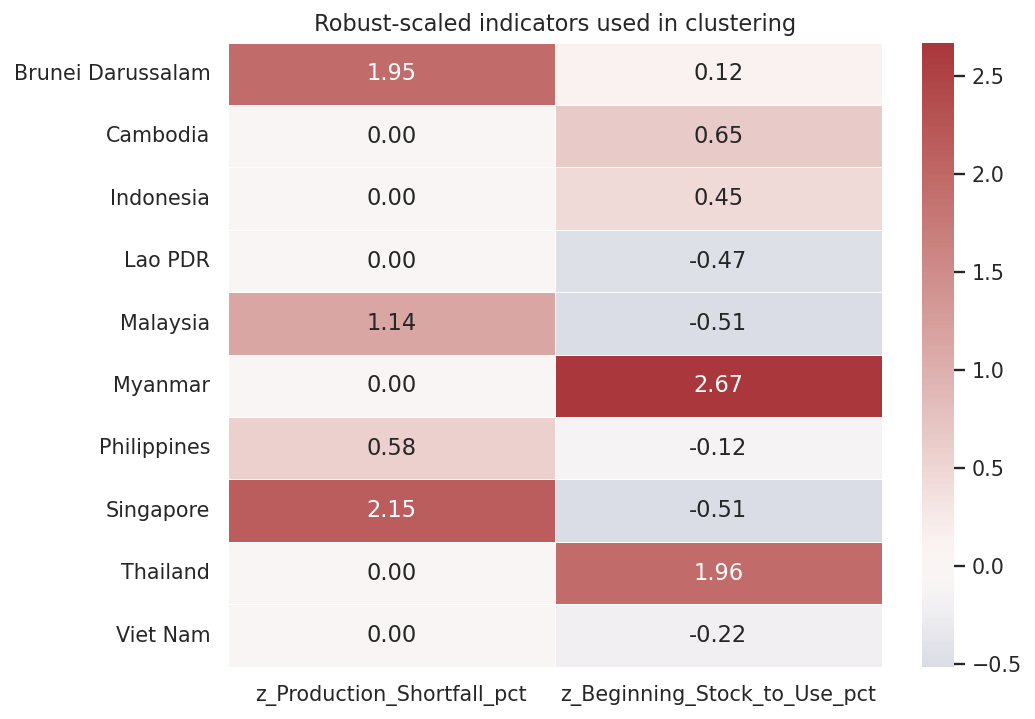

In [10]:
robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(main_sample[MAIN_FEATURES])

scaled_columns = [f"z_{c}" for c in MAIN_FEATURES]
scaled_df = pd.DataFrame(X_robust, columns=scaled_columns)
scaled_df.insert(0, "Country", main_sample["Country"])

print("Median asli:", dict(zip(MAIN_FEATURES, robust_scaler.center_.round(3))))
print("IQR asli   :", dict(zip(MAIN_FEATURES, robust_scaler.scale_.round(3))))
print(scaled_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    scaled_df.set_index("Country"), cmap="vlag", center=0,
    annot=True, fmt=".2f", linewidths=0.5, ax=ax
)
ax.set_title("Robust-scaled indicators used in clustering")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 8. Percobaan hierarchical clustering untuk $k=2$, $k=3$, dan $k=4$

Metode Ward dipilih karena jumlah negara kecil dan dendrogramnya mudah dijelaskan. Ward meminimalkan pertambahan variasi di dalam cluster pada setiap tahap penggabungan.

Tiga ukuran validasi dibandingkan:

- **Silhouette**: lebih tinggi lebih baik.
- **Calinski-Harabasz**: lebih tinggi lebih baik.
- **Davies-Bouldin**: lebih rendah lebih baik.

Ukuran cluster juga diperiksa. Nomor cluster diurutkan secara konsisten dari centroid dengan production gap lebih besar menuju buffer yang lebih kuat. Nomor tersebut tetap hanya ID, bukan peringkat risiko resmi.


In [11]:
def order_cluster_ids(raw_labels, frame):
    temp = frame[["Country"] + MAIN_FEATURES].copy()
    temp["raw_label"] = raw_labels
    centroids = temp.groupby("raw_label")[MAIN_FEATURES].mean()
    ordered_old_ids = centroids.sort_values(
        ["Production_Shortfall_pct", "Beginning_Stock_to_Use_pct"],
        ascending=[False, True],
    ).index.tolist()
    mapping = {old: f"C{rank + 1}" for rank, old in enumerate(ordered_old_ids)}
    return pd.Series(raw_labels).map(mapping).to_numpy()

cluster_models = {}
metric_rows = []

for k in [2, 3, 4]:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    raw_labels = model.fit_predict(X_robust)
    ordered_labels = order_cluster_ids(raw_labels, main_sample)
    cluster_models[k] = {
        "model": model,
        "raw_labels": raw_labels,
        "labels": ordered_labels,
    }
    sizes = pd.Series(ordered_labels).value_counts()
    metric_rows.append({
        "k": k,
        "Silhouette": silhouette_score(X_robust, raw_labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_robust, raw_labels),
        "Davies_Bouldin": davies_bouldin_score(X_robust, raw_labels),
        "Minimum_Cluster_Size": int(sizes.min()),
        "Maximum_Cluster_Size": int(sizes.max()),
        "Has_Singleton": bool((sizes == 1).any()),
    })
    main_sample[f"Cluster_k{k}"] = ordered_labels

cluster_metrics = pd.DataFrame(metric_rows)
print(cluster_metrics.round(4).to_string(index=False))

membership_table = main_sample[["Country", "Cluster_k2", "Cluster_k3", "Cluster_k4"]]
print("\nKeanggotaan cluster:")
print(membership_table.to_string(index=False))


 k  Silhouette  Calinski_Harabasz  Davies_Bouldin  Minimum_Cluster_Size  Maximum_Cluster_Size  Has_Singleton
 2      0.5355            10.7117          0.4906                     2                     8          False
 3      0.5278            18.6338          0.4707                     2                     6          False
 4      0.4714            21.3457          0.4936                     2                     4          False

Keanggotaan cluster:
          Country Cluster_k2 Cluster_k3 Cluster_k4
Brunei Darussalam         C1         C1         C1
         Cambodia         C1         C2         C3
        Indonesia         C1         C2         C3
          Lao PDR         C1         C2         C2
         Malaysia         C1         C2         C2
          Myanmar         C2         C3         C4
      Philippines         C1         C2         C2
        Singapore         C1         C1         C1
         Thailand         C2         C3         C4
         Viet Nam         C1    

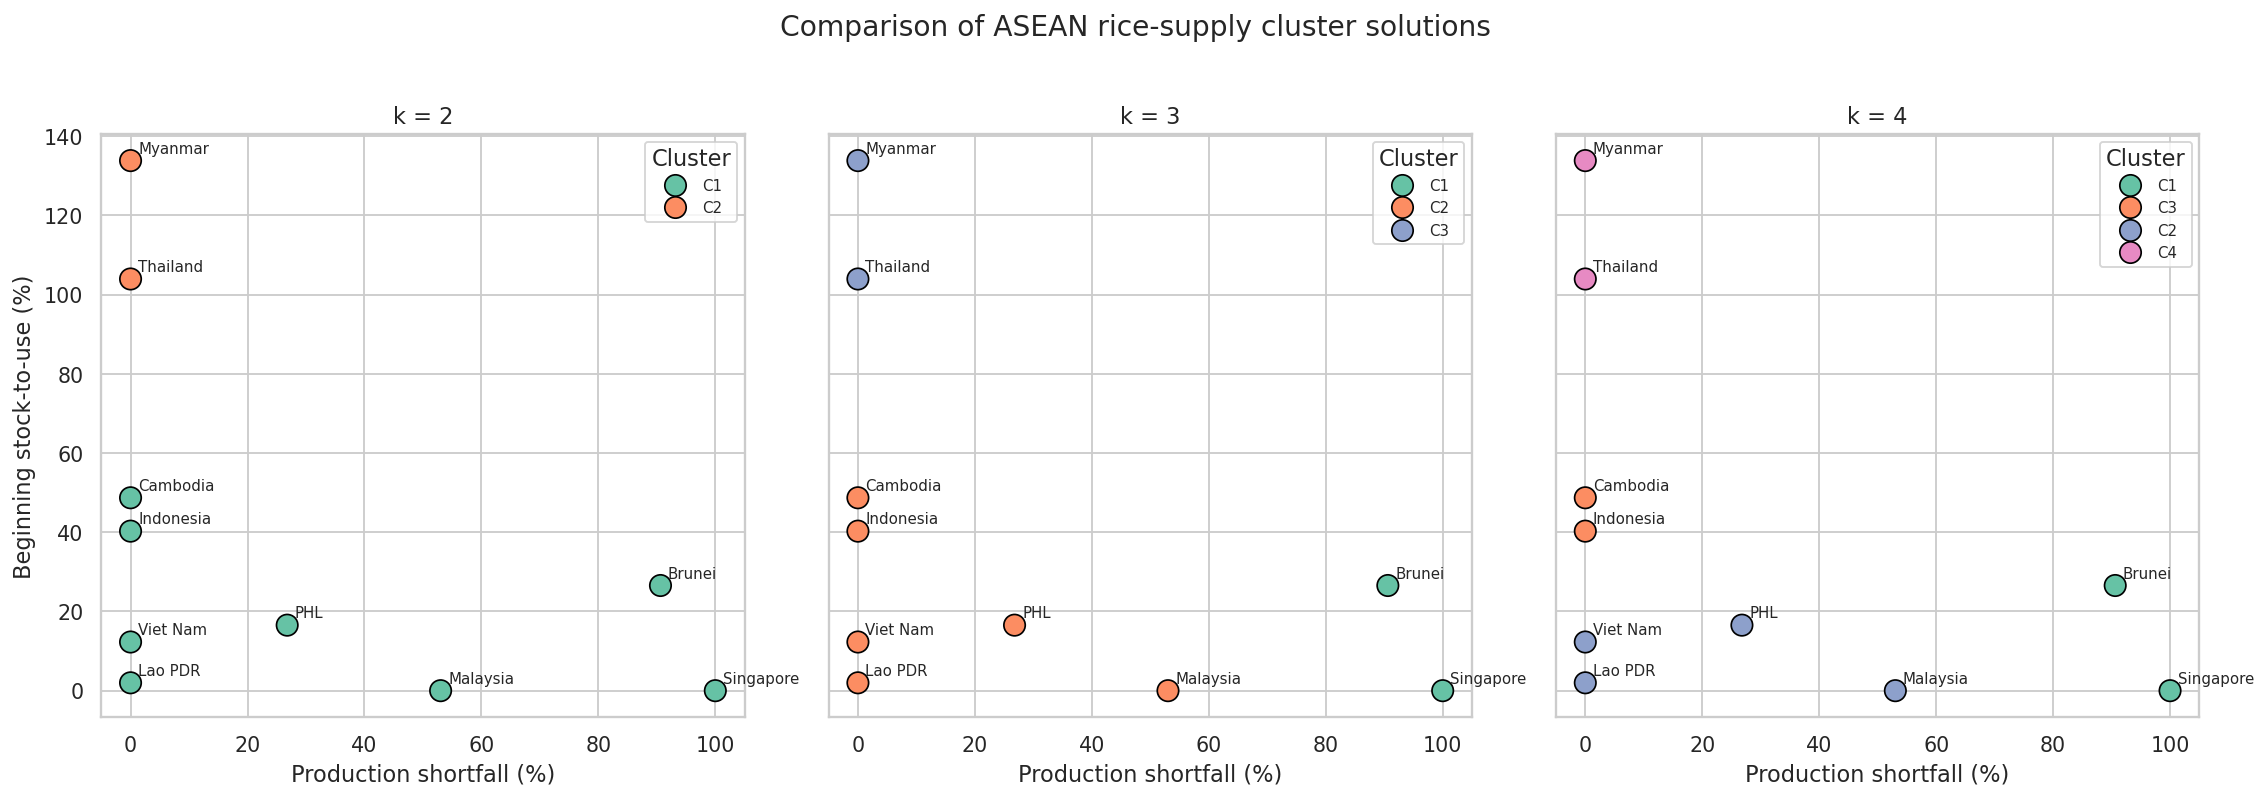

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.8), sharex=True, sharey=True)

for ax, k in zip(axes, [2, 3, 4]):
    cluster_col = f"Cluster_k{k}"
    sns.scatterplot(
        data=main_sample,
        x="Production_Shortfall_pct",
        y="Beginning_Stock_to_Use_pct",
        hue=cluster_col,
        palette="Set2",
        s=130,
        edgecolor="black",
        ax=ax,
    )
    for _, row in main_sample.iterrows():
        label = row["Country"].replace("Brunei Darussalam", "Brunei").replace("Philippines", "PHL")
        ax.annotate(label, (row["Production_Shortfall_pct"], row["Beginning_Stock_to_Use_pct"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Production shortfall (%)")
    ax.set_ylabel("Beginning stock-to-use (%)")
    ax.legend(title="Cluster", fontsize=8)

fig.suptitle("Comparison of ASEAN rice-supply cluster solutions", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


## 9. Dendrogram

Dendrogram memperlihatkan urutan negara digabungkan berdasarkan kemiripan indikator. Cabang yang bertemu pada ketinggian rendah berarti profilnya lebih mirip. Dendrogram membantu melihat apakah pemotongan menjadi dua, tiga, atau empat cluster didukung oleh jarak yang cukup jelas.


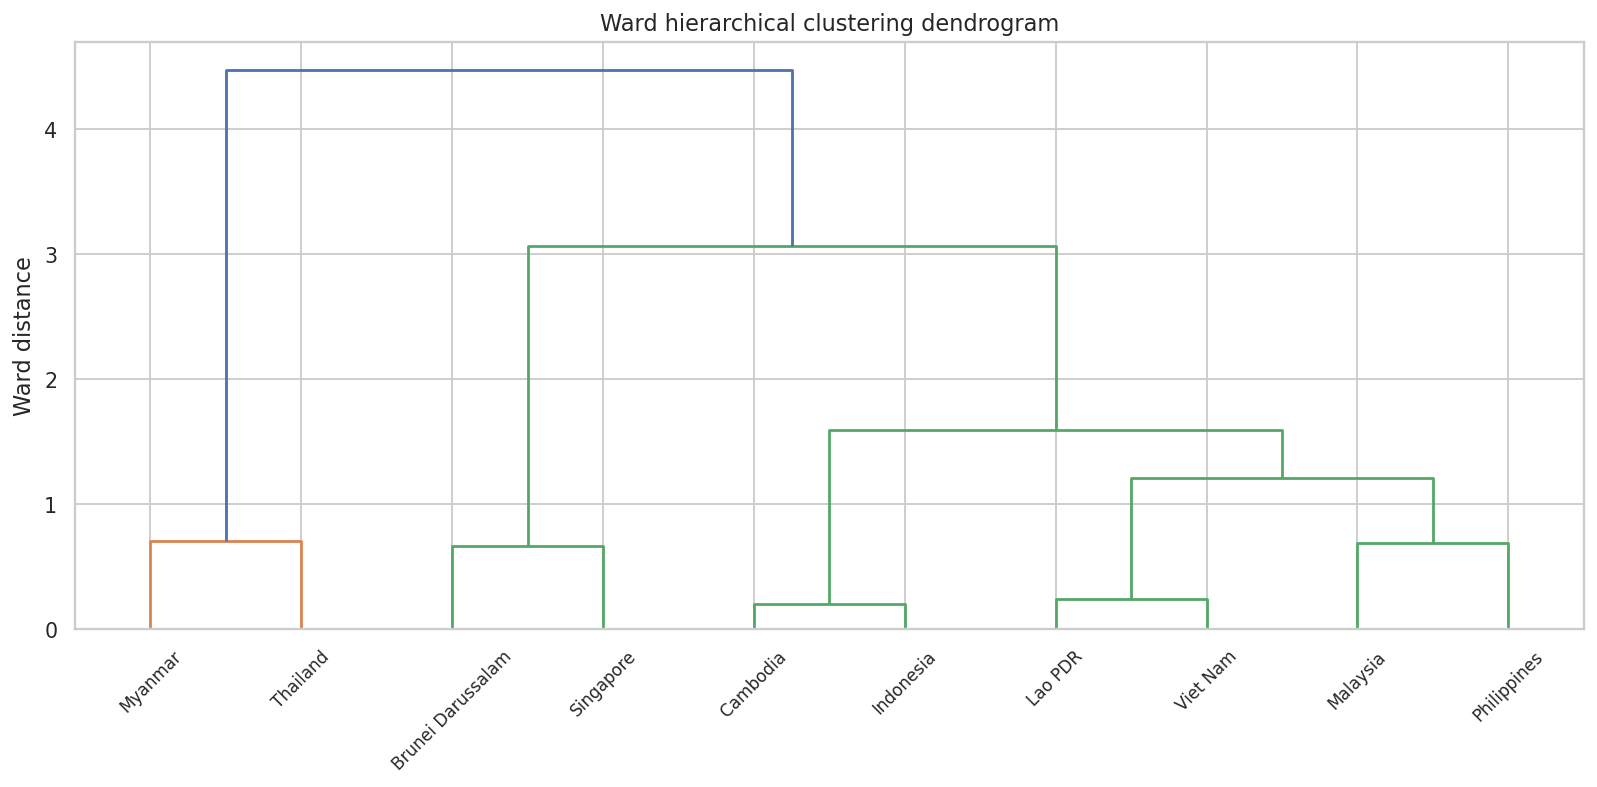

In [13]:
Z = linkage(X_robust, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    Z,
    labels=main_sample["Country"].tolist(),
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=None,
    ax=ax,
)
ax.set_title("Ward hierarchical clustering dendrogram")
ax.set_ylabel("Ward distance")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 10. Sensitivity check terhadap metode standardisasi

Cluster dihitung ulang dengan StandardScaler. Kesamaan hasil RobustScaler dan StandardScaler dinilai menggunakan Adjusted Rand Index (ARI):

- ARI mendekati 1 berarti keanggotaan sangat konsisten;
- ARI mendekati 0 berarti kesamaannya tidak lebih baik dari kebetulan;
- nilai rendah untuk $k=4$ menunjukkan solusi empat cluster sensitif terhadap cara data distandarkan.


In [14]:
X_standard = StandardScaler().fit_transform(main_sample[MAIN_FEATURES])
scaling_stability = []

for k in [2, 3, 4]:
    robust_raw = cluster_models[k]["raw_labels"]
    standard_raw = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_standard)
    scaling_stability.append({
        "k": k,
        "Adjusted_Rand_Index_Robust_vs_Standard": adjusted_rand_score(robust_raw, standard_raw),
    })

scaling_stability = pd.DataFrame(scaling_stability)
cluster_metrics = cluster_metrics.merge(scaling_stability, on="k", how="left")

# Multi-criteria rank sederhana. Nilai lebih kecil lebih baik.
cluster_metrics["Rank_Silhouette"] = cluster_metrics["Silhouette"].rank(ascending=False, method="min")
cluster_metrics["Rank_CH"] = cluster_metrics["Calinski_Harabasz"].rank(ascending=False, method="min")
cluster_metrics["Rank_DB"] = cluster_metrics["Davies_Bouldin"].rank(ascending=True, method="min")
cluster_metrics["Composite_Rank_Sum"] = cluster_metrics[[
    "Rank_Silhouette", "Rank_CH", "Rank_DB"
]].sum(axis=1)

recommended_k = int(
    cluster_metrics.sort_values(
        ["Composite_Rank_Sum", "Adjusted_Rand_Index_Robust_vs_Standard", "k"],
        ascending=[True, False, True],
    ).iloc[0]["k"]
)

print(cluster_metrics.round(4).to_string(index=False))
print(f"\nSolusi kerja yang direkomendasikan notebook: k = {recommended_k}")
print("Rekomendasi tetap eksploratif karena n hanya", len(main_sample), "negara.")


 k  Silhouette  Calinski_Harabasz  Davies_Bouldin  Minimum_Cluster_Size  Maximum_Cluster_Size  Has_Singleton  Adjusted_Rand_Index_Robust_vs_Standard  Rank_Silhouette  Rank_CH  Rank_DB  Composite_Rank_Sum
 2      0.5355            10.7117          0.4906                     2                     8          False                                  1.0000              1.0      3.0      2.0                 6.0
 3      0.5278            18.6338          0.4707                     2                     6          False                                  1.0000              2.0      2.0      1.0                 5.0
 4      0.4714            21.3457          0.4936                     2                     4          False                                  0.4444              3.0      1.0      3.0                 7.0

Solusi kerja yang direkomendasikan notebook: k = 3
Rekomendasi tetap eksploratif karena n hanya 10 negara.


## 11. Membentuk profil cluster terpilih

Nama profil dibuat **setelah** cluster terbentuk, berdasarkan centroid production shortfall dan stock-to-use. Nama ini membantu pembaca memahami pola rata-rata, tetapi tidak mengubah perhitungan algoritma.


In [15]:
selected_cluster_col = f"Cluster_k{recommended_k}"

def descriptive_profile_name(row):
    gap = row["Mean_Production_Shortfall_pct"]
    stock = row["Mean_Beginning_Stock_to_Use_pct"]
    if gap >= 60 and stock < 30:
        return "Large domestic gap, limited stocks"
    if gap >= 60:
        return "Large domestic gap, stock-supported"
    if gap >= 10 and stock < 30:
        return "Mixed or partial gap, limited stocks"
    if gap >= 10:
        return "Mixed or partial gap, stock-supported"
    if stock >= 75:
        return "Domestic surplus, deep stocks"
    if stock >= 25:
        return "Domestic surplus, moderate stocks"
    return "Domestic surplus, limited stocks"

cluster_profiles = (
    main_sample.groupby(selected_cluster_col)
    .agg(
        Countries=("Country", "size"),
        Mean_Production_Shortfall_pct=("Production_Shortfall_pct", "mean"),
        Mean_Beginning_Stock_to_Use_pct=("Beginning_Stock_to_Use_pct", "mean"),
        Mean_SSR_pct=("SSR_pct", "mean"),
        Country_List=("Country", lambda s: ", ".join(sorted(s))),
    )
    .reset_index()
)
cluster_profiles["Profile_Name"] = cluster_profiles.apply(descriptive_profile_name, axis=1)

profile_name_map = cluster_profiles.set_index(selected_cluster_col)["Profile_Name"]
main_sample["Selected_Cluster"] = main_sample[selected_cluster_col]
main_sample["Selected_Profile"] = main_sample["Selected_Cluster"].map(profile_name_map)

master = master.merge(
    main_sample[["Country", "Cluster_k2", "Cluster_k3", "Cluster_k4", "Selected_Cluster", "Selected_Profile"]],
    on="Country",
    how="left",
)

print(cluster_profiles.round(2).to_string(index=False))
print("\nHasil per negara:")
print(main_sample[["Country", "Selected_Cluster", "Selected_Profile"]].to_string(index=False))


Cluster_k3  Countries  Mean_Production_Shortfall_pct  Mean_Beginning_Stock_to_Use_pct  Mean_SSR_pct                                                  Country_List                         Profile_Name
        C1          2                          95.31                            13.28          4.69                                  Brunei Darussalam, Singapore   Large domestic gap, limited stocks
        C2          6                          13.30                            19.97         99.30 Cambodia, Indonesia, Lao PDR, Malaysia, Philippines, Viet Nam Mixed or partial gap, limited stocks
        C3          2                           0.00                           118.90        165.68                                             Myanmar, Thailand        Domestic surplus, deep stocks

Hasil per negara:
          Country Selected_Cluster                     Selected_Profile
Brunei Darussalam               C1   Large domestic gap, limited stocks
         Cambodia               C2 Mixed 

## 12. Diagnosis tambahan dari data climate dan supplier concentration

Tabel ini tidak membentuk cluster utama. Tujuannya menunjukkan informasi tambahan yang sudah berhasil dihitung dan bagian yang masih terbatas cakupannya.

Koefisien climate dengan interval lebar atau $p \geq 0.05$ tidak boleh ditulis sebagai bukti dampak yang pasti. Demikian juga, HHI hanya tersedia untuk empat reporter sehingga belum layak dipaksakan ke seluruh ASEAN.


In [16]:
diagnostic_columns = [
    "Country", "Supplier_HHI", "Effective_Suppliers", "Top_Supplier",
    "Top_Supplier_Share_pct", "Yield_RONI_Beta_pp_per_1C", "Yield_RONI_pvalue",
    "Climate_Evidence", "Climate_Supplier_Coverage_pct",
    "Supplier_Climate_Exposure_pp_per_1C",
]
print(master[diagnostic_columns].round(3).to_string(index=False))

print("\nCatatan:")
print("- HHI tersedia untuk", int(master["Supplier_HHI"].notna().sum()), "negara reporter.")
print("- Supplier climate exposure lolos coverage >=80% untuk", int(master["Supplier_Climate_Exposure_pp_per_1C"].notna().sum()), "negara.")
print("- Estimasi respons yield domestik tersedia untuk", int(master["Yield_RONI_Beta_pp_per_1C"].notna().sum()), "negara.")


          Country  Supplier_HHI  Effective_Suppliers Top_Supplier  Top_Supplier_Share_pct  Yield_RONI_Beta_pp_per_1C  Yield_RONI_pvalue        Climate_Evidence  Climate_Supplier_Coverage_pct  Supplier_Climate_Exposure_pp_per_1C
Brunei Darussalam         0.477                2.097     Thailand                  62.319                      7.811              0.396 No negative association                         91.738                                2.045
         Cambodia           NaN                  NaN          NaN                     NaN                     -4.911              0.017        Negative, p<0.05                            NaN                                  NaN
        Indonesia           NaN                  NaN          NaN                     NaN                      1.544              0.043 No negative association                            NaN                                  NaN
          Lao PDR           NaN                  NaN          NaN                     Na

## 13. Peta cluster ASEAN

Shapefile bukan satu file tunggal. Agar dapat dibaca, paling tidak komponen `.shp`, `.shx`, dan `.dbf` harus berada pada folder yang sama dengan nama dasar identik. File `.prj` juga sebaiknya tersedia agar sistem koordinat terbaca dengan benar.

Cell akan menggunakan path milikmu:

`C:\Users\ACER\OneDrive\Dokumen\COMPETITION\RASIO\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp`

Jika komponen atau `geopandas` belum tersedia, analisis lain tetap berjalan dan cell hanya menampilkan petunjuk perbaikan.


In [17]:
required_sidecars = [SHP_PATH.with_suffix(".shx"), SHP_PATH.with_suffix(".dbf")]
missing_sidecars = [str(p) for p in required_sidecars if not p.exists()]
map_was_created = False

if not SHP_PATH.exists():
    print("Peta dilewati: file .shp tidak ditemukan pada path yang diperiksa.")
elif missing_sidecars:
    print("Peta dilewati karena komponen shapefile belum lengkap:")
    for item in missing_sidecars:
        print(" -", item)
    print("Salin seluruh isi folder Natural Earth, bukan hanya file .shp.")
else:
    try:
        import geopandas as gpd

        world = gpd.read_file(SHP_PATH)
        name_candidates = ["ADMIN", "SOVEREIGNT", "NAME", "NAME_EN", "FORMAL_EN"]
        name_col = next((c for c in name_candidates if c in world.columns), None)
        if name_col is None:
            raise KeyError(f"Kolom nama negara tidak ditemukan. Kolom tersedia: {world.columns.tolist()}")

        geo_name_map = {
            "Brunei": "Brunei Darussalam",
            "East Timor": "Timor-Leste",
            "Lao PDR": "Lao PDR",
            "Laos": "Lao PDR",
            "Vietnam": "Viet Nam",
        }
        world["Country"] = world[name_col].replace(geo_name_map)
        asean_geo = world.loc[world["Country"].isin(ASEAN_2026)].copy()
        asean_geo = asean_geo.merge(
            master[["Country", "Selected_Cluster", "Selected_Profile"]],
            on="Country", how="left"
        )

        fig, ax = plt.subplots(figsize=(11, 9))
        asean_geo.plot(
            column="Selected_Cluster",
            categorical=True,
            cmap="Set2",
            linewidth=0.6,
            edgecolor="white",
            legend=True,
            missing_kwds={"color": "lightgrey", "label": "No comparable AFSIS data"},
            ax=ax,
        )
        ax.set_title(f"ASEAN rice-supply profiles, selected k = {recommended_k}", fontsize=15)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()
        map_was_created = True
        print("Peta berhasil dibuat untuk", len(asean_geo), "geometri negara ASEAN.")
    except ImportError:
        print("Peta dilewati: geopandas belum terpasang.")
        print("Jalankan `%pip install geopandas pyogrio` pada environment notebook, lalu ulangi cell ini.")
    except Exception as exc:
        print("Peta belum dapat dibuat:", repr(exc))


Peta dilewati karena komponen shapefile belum lengkap:
 - /workspace/scratch/faabc4ee17d4/upload/ne_10m_admin_0_countries.shx
 - /workspace/scratch/faabc4ee17d4/upload/ne_10m_admin_0_countries.dbf
Salin seluruh isi folder Natural Earth, bukan hanya file .shp.


In [ ]:
# Peta perbandingan hasil clustering.
# Gunakan [2, 3, 4] untuk membandingkan semua solusi, atau misalnya [3] untuk satu peta saja.
MAP_K_VALUES = [2, 3, 4]

from matplotlib.patches import Patch

cluster_colors = {
    "C1": "#D95F59",
    "C2": "#F2B134",
    "C3": "#4AA8A1",
    "C4": "#4776B4",
}
no_data_color = "#D9D9D9"

# Posisi label dibuat manual agar negara kecil dan kepulauan tetap mudah dibaca.
label_positions = {
    "Brunei Darussalam": (114.7, 4.6, "BRN"),
    "Cambodia": (104.9, 12.7, "KHM"),
    "Indonesia": (118.0, -2.6, "IDN"),
    "Lao PDR": (102.6, 18.2, "LAO"),
    "Malaysia": (102.0, 4.2, "MYS"),
    "Myanmar": (96.7, 20.5, "MMR"),
    "Philippines": (122.2, 12.5, "PHL"),
    "Singapore": (103.8, 1.3, "SGP"),
    "Thailand": (101.0, 15.3, "THA"),
    "Timor-Leste": (125.9, -8.8, "TLS"),
    "Viet Nam": (107.8, 16.0, "VNM"),
}

required_sidecars = [SHP_PATH.with_suffix(".shx"), SHP_PATH.with_suffix(".dbf")]
missing_sidecars = [p for p in required_sidecars if not p.exists()]

if not SHP_PATH.exists() or missing_sidecars:
    print("Peta belum dapat dibuat. Pastikan file .shp, .shx, dan .dbf berada dalam folder yang sama.")
    print("Path yang diperiksa:", SHP_PATH)
else:
    try:
        import geopandas as gpd

        world_map = gpd.read_file(SHP_PATH)
        name_candidates = ["ADMIN", "SOVEREIGNT", "NAME", "NAME_EN", "FORMAL_EN"]
        name_col = next((c for c in name_candidates if c in world_map.columns), None)
        if name_col is None:
            raise KeyError(f"Kolom nama negara tidak ditemukan. Kolom tersedia: {world_map.columns.tolist()}")

        geo_name_map = {
            "Brunei": "Brunei Darussalam",
            "East Timor": "Timor-Leste",
            "Laos": "Lao PDR",
            "Vietnam": "Viet Nam",
        }
        world_map["Country"] = world_map[name_col].replace(geo_name_map)
        asean_map = world_map.loc[world_map["Country"].isin(ASEAN_2026)].copy()
        asean_map = asean_map.merge(
            master[["Country", "Cluster_k2", "Cluster_k3", "Cluster_k4"]],
            on="Country",
            how="left",
        )

        n_maps = len(MAP_K_VALUES)
        fig, axes = plt.subplots(1, n_maps, figsize=(7.2 * n_maps, 7.0), squeeze=False)
        axes = axes.ravel()

        for ax, k in zip(axes, MAP_K_VALUES):
            cluster_col = f"Cluster_k{k}"
            ax.set_facecolor("#F6F8FA")

            # Lapisan dasar juga membuat Timor-Leste tetap terlihat meskipun belum memiliki cluster.
            asean_map.plot(
                ax=ax, color=no_data_color, edgecolor="white", linewidth=0.65
            )
            for cluster_id in [f"C{i}" for i in range(1, k + 1)]:
                subset = asean_map.loc[asean_map[cluster_col] == cluster_id]
                if not subset.empty:
                    subset.plot(
                        ax=ax,
                        color=cluster_colors[cluster_id],
                        edgecolor="white",
                        linewidth=0.65,
                    )

            for country, (x, y, abbreviation) in label_positions.items():
                if country in set(asean_map["Country"]):
                    ax.text(
                        x, y, abbreviation, ha="center", va="center",
                        fontsize=8, fontweight="bold", color="#202124",
                        bbox={"boxstyle": "round,pad=0.18", "facecolor": "white",
                              "edgecolor": "none", "alpha": 0.72},
                    )

            ax.set_xlim(92, 142)
            ax.set_ylim(-13, 29)
            ax.set_title(f"k = {k}", fontsize=16, fontweight="bold", pad=10)
            ax.set_axis_off()

        legend_handles = [
            Patch(facecolor=cluster_colors[f"C{i}"], label=f"Cluster C{i}")
            for i in range(1, max(MAP_K_VALUES) + 1)
        ]
        legend_handles.append(Patch(facecolor=no_data_color, label="No comparable data"))

        fig.suptitle(
            "ASEAN Rice-Supply Clusters: Comparison of k = 2, 3, and 4",
            fontsize=18, fontweight="bold", y=0.98,
        )
        fig.legend(
            handles=legend_handles, loc="lower center", ncol=len(legend_handles),
            frameon=False, bbox_to_anchor=(0.5, 0.02),
        )
        plt.tight_layout(rect=[0, 0.08, 1, 0.94])
        plt.show()

    except ImportError:
        print("Geopandas belum terpasang. Jalankan: %pip install geopandas pyogrio")
    except Exception as exc:
        print("Peta belum dapat dibuat:", repr(exc))


## 14. Menyimpan hasil

Cell terakhir menyimpan dataframe master, keanggotaan cluster, metrik evaluasi, dan centroid profil sebagai CSV. File ini dapat langsung digunakan untuk infografis atau pemeriksaan lanjutan.


In [18]:
OUTPUT_DIR = Path.cwd() / "outputs_asean_clustering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master_path = OUTPUT_DIR / "asean_master_dataframe.csv"
membership_path = OUTPUT_DIR / "asean_cluster_memberships_k2_k3_k4.csv"
metrics_path = OUTPUT_DIR / "cluster_validation_metrics.csv"
profiles_path = OUTPUT_DIR / "selected_cluster_profiles.csv"

master.to_csv(master_path, index=False)
membership_table.to_csv(membership_path, index=False)
cluster_metrics.to_csv(metrics_path, index=False)
cluster_profiles.to_csv(profiles_path, index=False)

print("Tersimpan:")
for path in [master_path, membership_path, metrics_path, profiles_path]:
    print(" -", path)


Tersimpan:
 - /workspace/scratch/faabc4ee17d4/outputs_asean_clustering/asean_master_dataframe.csv
 - /workspace/scratch/faabc4ee17d4/outputs_asean_clustering/asean_cluster_memberships_k2_k3_k4.csv
 - /workspace/scratch/faabc4ee17d4/outputs_asean_clustering/cluster_validation_metrics.csv
 - /workspace/scratch/faabc4ee17d4/outputs_asean_clustering/selected_cluster_profiles.csv


## 15. Cara membaca dan melaporkan hasil

Gunakan kalimat yang berhati-hati:

> Hierarchical clustering identifies exploratory rice-supply profiles among the ten ASEAN countries covered by the AFSIS 2026 tables. The selected solution is supported by a combination of internal validation and scaling stability, while Timor-Leste remains unclassified because comparable AFSIS balance data are not yet present in the supplied dataset.

Jangan menulis bahwa cluster tertinggi pasti mengalami krisis. Model utama hanya memotret domestic production gap dan stock buffer. Supplier concentration serta climate exposure belum lengkap untuk seluruh negara.

### Data yang perlu ditambahkan agar model berikutnya lebih kuat

1. UN Comtrade HS 1006 tahun 2024 untuk **seluruh 11 reporter ASEAN**, bukan hanya empat negara.
2. Yield historis pemasok besar non-ASEAN, terutama India dan Pakistan, agar coverage supplier climate exposure meningkat.
3. Neraca beras Timor-Leste dengan definisi yang sama seperti tabel AFSIS.
4. Seluruh komponen shapefile `.shp`, `.shx`, `.dbf`, dan `.prj` pada satu folder.
